In [6]:
!pip install datasets pymorphy3 spacy scikit-learn matplotlib seaborn wordcloud
!python -m spacy download ru_core_news_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 84.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [7]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from datasets import load_dataset
import spacy
import pymorphy3
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('ggplot')
sns.set_palette("husl")
nlp = spacy.load("ru_core_news_sm")
morph = pymorphy3.MorphAnalyzer()

In [8]:
# @title 2. Загрузка датасета новостей
# Загружаем датасет с Hugging Face
ds = load_dataset("data-silence/rus_news_classifier")

# Смотрим распределение меток
df = pd.DataFrame(ds['train'])
print("Распределение по категориям:")
print(df['labels'].value_counts().sort_index())

# Выбираем два домена для сравнения (например, 1 - технологии, 4 - происшествия/криминал)
# Но лучше взять наиболее разные по смыслу
label_names = {
    0: "Криминал/Происшествия",
    1: "Технологии",
    2: "Политика/Международные",
    3: "Спорт",
    4: "Разное/Лайфстайл",
    5: "Культура",
    6: "Экономика",
    7: "Наука",
    8: "Общество",
    9: "Армия/Оборона"
}

# Для анализа выберем две контрастные темы
# Например, "Технологии" (1) и "Криминал" (0)
domain1 = df[df['labels'] == 1].copy()  # Технологии
domain2 = df[df['labels'] == 0].copy()  # Криминал

print(f"\nВыбраны домены:")
print(f"Домен A (Технологии): {len(domain1)} текстов")
print(f"Домен B (Криминал): {len(domain2)} текстов")

# Возьмем равное количество для баланса
n_samples = min(1000, len(domain1), len(domain2))
domain1 = domain1.sample(n_samples, random_state=42)
domain2 = domain2.sample(n_samples, random_state=42)

print(f"\nПосле балансировки: по {n_samples} текстов")

Распределение по категориям:
labels
0     3712
1     6277
2     4573
3     5636
4     7993
5     4931
6     5558
7     5406
8     4937
9     4791
10    3716
Name: count, dtype: int64

Выбраны домены:
Домен A (Технологии): 6277 текстов
Домен B (Криминал): 3712 текстов

После балансировки: по 1000 текстов


In [9]:
# @title A1. Функции предобработки
def preprocess_text(text, lemmatize=False, remove_stops=False, ngram_range=(1,1)):
    """Предобработка текста с разными опциями"""
    # Очистка
    text = text.lower()
    text = re.sub(r'[^а-яё\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    if lemmatize:
        doc = nlp(text[:10000])  # Ограничиваем длину
        words = [token.lemma_ for token in doc if token.is_alpha]
    else:
        words = text.split()

    if remove_stops:
        stops = nlp.Defaults.stop_words
        words = [w for w in words if w not in stops]

    return ' '.join(words)

def get_features(texts, lemmatize=False, remove_stops=False, ngram_range=(1,1), max_features=1000):
    """Превращает тексты в матрицу признаков"""
    vectorizer = CountVectorizer(
        max_features=max_features,
        ngram_range=ngram_range,
        preprocessor=lambda x: preprocess_text(x, lemmatize, remove_stops)
    )
    X = vectorizer.fit_transform(texts)
    return X, vectorizer

print("✓ Функции готовы")

✓ Функции готовы


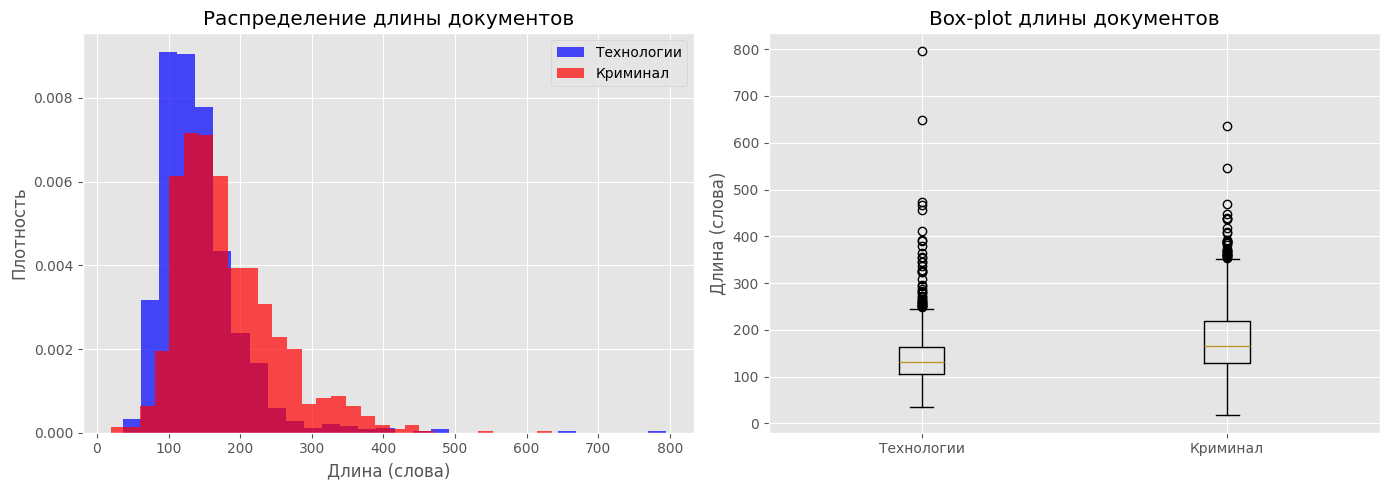

Средняя длина - Технологии: 142.4, Криминал: 182.4


In [10]:
# @title A2. Базовое сравнение распределений
# Подготовим тексты
texts_d1 = domain1['news'].tolist()
texts_d2 = domain2['news'].tolist()
all_texts = texts_d1 + texts_d2
labels = [0]*len(texts_d1) + [1]*len(texts_d2)

# 1. Длина документов
len_d1 = [len(t.split()) for t in texts_d1]
len_d2 = [len(t.split()) for t in texts_d2]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(len_d1, bins=30, alpha=0.7, label='Технологии', color='blue', density=True)
plt.hist(len_d2, bins=30, alpha=0.7, label='Криминал', color='red', density=True)
plt.xlabel('Длина (слова)')
plt.ylabel('Плотность')
plt.title('Распределение длины документов')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot([len_d1, len_d2], labels=['Технологии', 'Криминал'])
plt.ylabel('Длина (слова)')
plt.title('Box-plot длины документов')

plt.tight_layout()
plt.show()

print(f"Средняя длина - Технологии: {np.mean(len_d1):.1f}, Криминал: {np.mean(len_d2):.1f}")

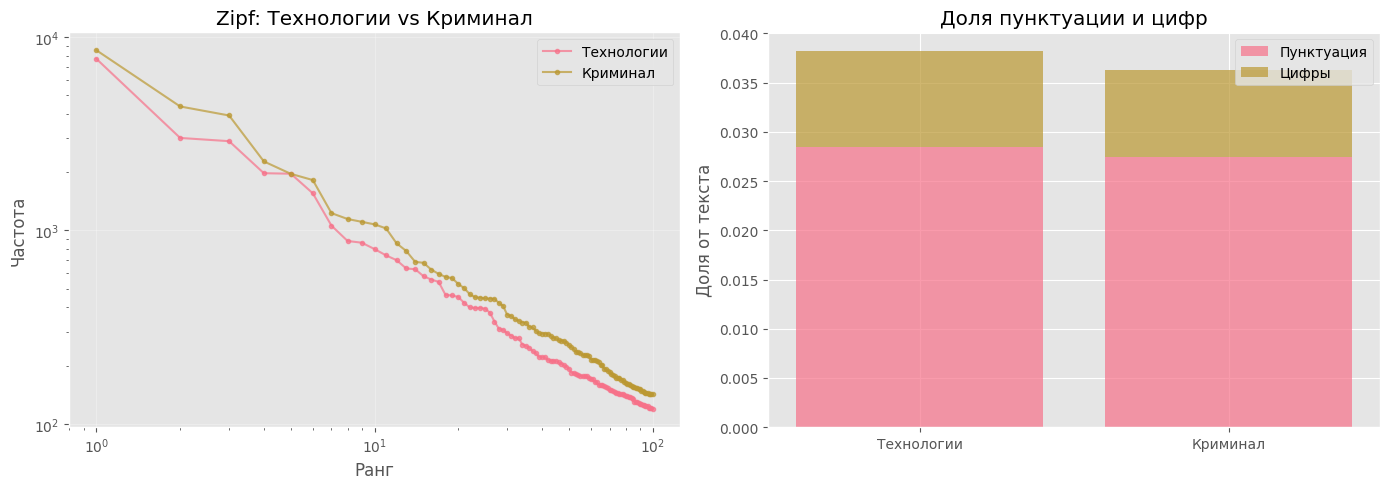

In [11]:
# @title A3. Сравнение Zipf-распределений (топ-100 токенов)
def plot_zipf(texts, label, ax):
    words = []
    for t in texts:
        words.extend(preprocess_text(t).split())
    cnt = Counter(words)
    freqs = sorted(cnt.values(), reverse=True)[:100]
    ranks = range(1, len(freqs)+1)
    ax.loglog(ranks, freqs, marker='.', label=label, alpha=0.7)
    ax.set_xlabel('Ранг')
    ax.set_ylabel('Частота')
    ax.grid(True, alpha=0.3)
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_zipf(texts_d1, 'Технологии', axes[0])
plot_zipf(texts_d2, 'Криминал', axes[0])
axes[0].set_title('Zipf: Технологии vs Криминал')

# Сравним также долю пунктуации/чисел
def get_punct_ratio(text):
    punct = len(re.findall(r'[^\w\s]', text))
    digits = len(re.findall(r'\d', text))
    total = len(text)
    return punct/total if total>0 else 0, digits/total if total>0 else 0

punct_d1 = [get_punct_ratio(t)[0] for t in texts_d1]
punct_d2 = [get_punct_ratio(t)[0] for t in texts_d2]
digits_d1 = [get_punct_ratio(t)[1] for t in texts_d1]
digits_d2 = [get_punct_ratio(t)[1] for t in texts_d2]

axes[1].bar(['Технологии', 'Криминал'], [np.mean(punct_d1), np.mean(punct_d2)], alpha=0.7, label='Пунктуация')
axes[1].bar(['Технологии', 'Криминал'], [np.mean(digits_d1), np.mean(digits_d2)], alpha=0.7, bottom=[np.mean(punct_d1), np.mean(punct_d2)], label='Цифры')
axes[1].set_ylabel('Доля от текста')
axes[1].set_title('Доля пунктуации и цифр')
axes[1].legend()

plt.tight_layout()
plt.show()

ТОП-30 ТОКЕНОВ, ХАРАКТЕРНЫХ ДЛЯ ТЕХНОЛОГИЙ:
                  token  freq_a  freq_b  log_odds
902           уголовное     125       0  5.070724
772                 скр      97       0  4.819409
607  правоохранительных      93       0  4.777736
104                 всу      86       0  4.700350
774       следственного      84       0  4.677093
90          вооруженных      71       0  4.511108
503              оружие      68       0  4.468548
896            убийстве      67       0  4.453949
351                 мвд     135       1  4.453949
222            задержан      67       0  4.453949
82           возбуждено      66       0  4.439134
571             полицию      65       0  4.424096
79              военный      62       0  4.377576
455               ножом      62       0  4.377576
878    террористической      60       0  4.345316
901          уголовного      59       0  4.328786
730             самолет      56       0  4.277493
556      подозреваемого      54       0  4.241775
252   

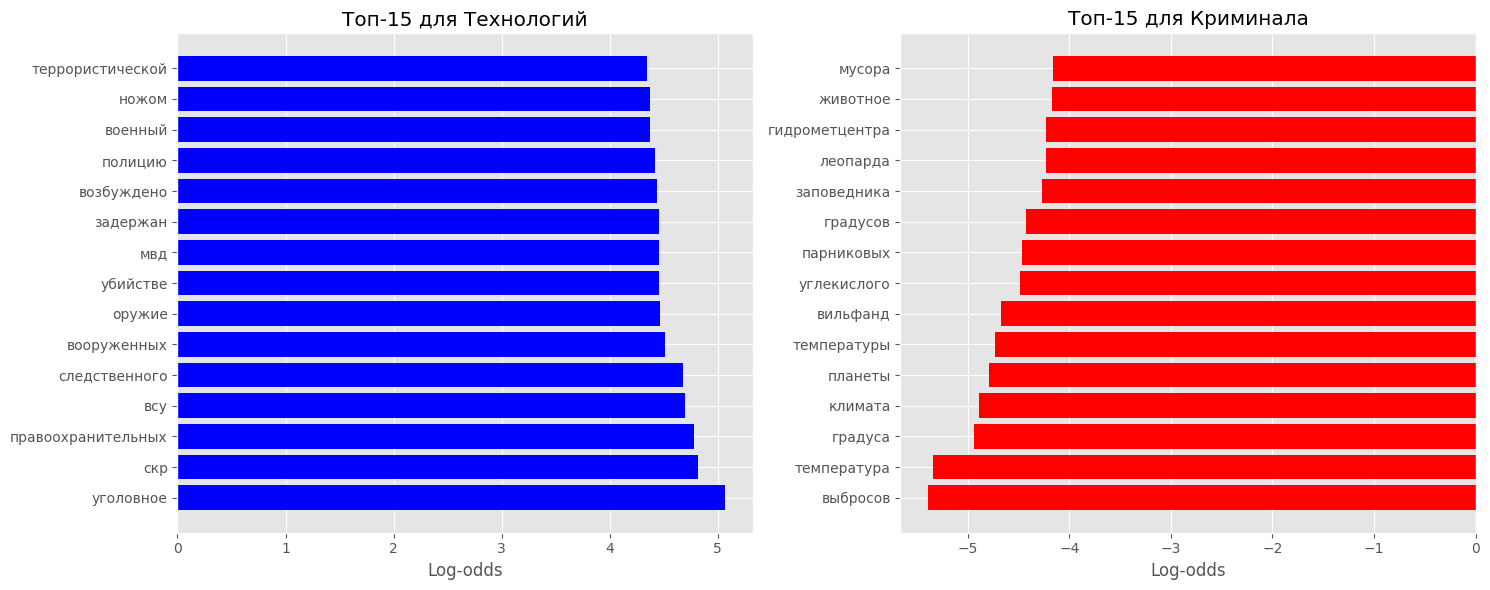

In [12]:
# @title A4. Анализ log-odds токенов (сравнение доменов)
from scipy.special import logit
from collections import defaultdict

def compute_log_odds(texts_a, texts_b, vectorizer, feature_names):
    """Вычисляет log-odds для токенов между двумя доменами"""
    X_a = vectorizer.transform(texts_a)
    X_b = vectorizer.transform(texts_b)

    # Частоты
    freq_a = np.array(X_a.sum(axis=0)).flatten() + 1  # +1 сглаживание
    freq_b = np.array(X_b.sum(axis=0)).flatten() + 1

    total_a = freq_a.sum()
    total_b = freq_b.sum()

    # Log-odds
    p_a = freq_a / total_a
    p_b = freq_b / total_b
    log_odds = np.log(p_a) - np.log(p_b)

    return pd.DataFrame({
        'token': feature_names,
        'freq_a': freq_a - 1,
        'freq_b': freq_b - 1,
        'log_odds': log_odds
    }).sort_values('log_odds', ascending=False)

# Базовый вариант (только токены)
vectorizer_base = CountVectorizer(max_features=1000, preprocessor=lambda x: preprocess_text(x, lemmatize=False))
X_base = vectorizer_base.fit_transform(all_texts)
feature_names_base = vectorizer_base.get_feature_names_out()

log_odds_base = compute_log_odds(texts_d1, texts_d2, vectorizer_base, feature_names_base)

print("ТОП-30 ТОКЕНОВ, ХАРАКТЕРНЫХ ДЛЯ ТЕХНОЛОГИЙ:")
print(log_odds_base.head(30).to_string())

print("\n" + "="*80)
print("ТОП-30 ТОКЕНОВ, ХАРАКТЕРНЫХ ДЛЯ КРИМИНАЛА:")
print(log_odds_base.tail(30).sort_values('log_odds').head(30).to_string())

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Топ для технологий
top_tech = log_odds_base.head(15)
axes[0].barh(range(len(top_tech)), top_tech['log_odds'].values, color='blue')
axes[0].set_yticks(range(len(top_tech)))
axes[0].set_yticklabels(top_tech['token'].values)
axes[0].set_title('Топ-15 для Технологий')
axes[0].set_xlabel('Log-odds')

# Топ для криминала
top_crime = log_odds_base.tail(15).sort_values('log_odds')
axes[1].barh(range(len(top_crime)), top_crime['log_odds'].values, color='red')
axes[1].set_yticks(range(len(top_crime)))
axes[1].set_yticklabels(top_crime['token'].values)
axes[1].set_title('Топ-15 для Криминала')
axes[1].set_xlabel('Log-odds')

plt.tight_layout()
plt.show()

In [13]:
# @title A5. Сравнение с лемматизацией, n-граммами, стоп-словами
variants = [
    {'name': 'Базовые токены', 'lemmatize': False, 'remove_stops': False, 'ngram': (1,1)},
    {'name': 'С лемматизацией', 'lemmatize': True, 'remove_stops': False, 'ngram': (1,1)},
    {'name': 'Без стоп-слов', 'lemmatize': False, 'remove_stops': True, 'ngram': (1,1)},
    {'name': 'Биграммы', 'lemmatize': False, 'remove_stops': False, 'ngram': (1,2)},
]

results_log_odds = {}

for var in variants:
    print(f"\n--- {var['name']} ---")

    # Создаем векторозотор
    vectorizer = CountVectorizer(
        max_features=1000,
        ngram_range=var['ngram'],
        preprocessor=lambda x: preprocess_text(x, var['lemmatize'], var['remove_stops'])
    )
    X = vectorizer.fit_transform(all_texts)
    feature_names = vectorizer.get_feature_names_out()

    # Считаем log-odds
    log_odds = compute_log_odds(texts_d1, texts_d2, vectorizer, feature_names)
    results_log_odds[var['name']] = log_odds

    print("Топ для технологий:", list(log_odds.head(10)['token']))
    print("Топ для криминала:", list(log_odds.tail(10)['token']))


--- Базовые токены ---
Топ для технологий: ['уголовное', 'скр', 'правоохранительных', 'всу', 'следственного', 'вооруженных', 'оружие', 'убийстве', 'мвд', 'задержан']
Топ для криминала: ['градусов', 'парниковых', 'углекислого', 'вильфанд', 'температуры', 'планеты', 'климата', 'градуса', 'температура', 'выбросов']

--- С лемматизацией ---
Топ для технологий: ['возбудить', 'правоохранительный', 'террористический', 'стрельба', 'истребитель', 'ракетный', 'скр', 'нож', 'всу', 'израиль']
Топ для криминала: ['загрязнение', 'леопард', 'углекислый', 'парниковый', 'вильфанд', 'градус', 'температура', 'климат', 'выброс', 'климатический']

--- Без стоп-слов ---
Топ для технологий: ['уголовное', 'скр', 'правоохранительных', 'всу', 'следственного', 'вооруженных', 'оружие', 'задержан', 'мвд', 'убийстве']
Топ для криминала: ['градусов', 'парниковых', 'углекислого', 'вильфанд', 'температуры', 'планеты', 'климата', 'градуса', 'температура', 'выбросов']

--- Биграммы ---
Топ для технологий: ['уголовное',

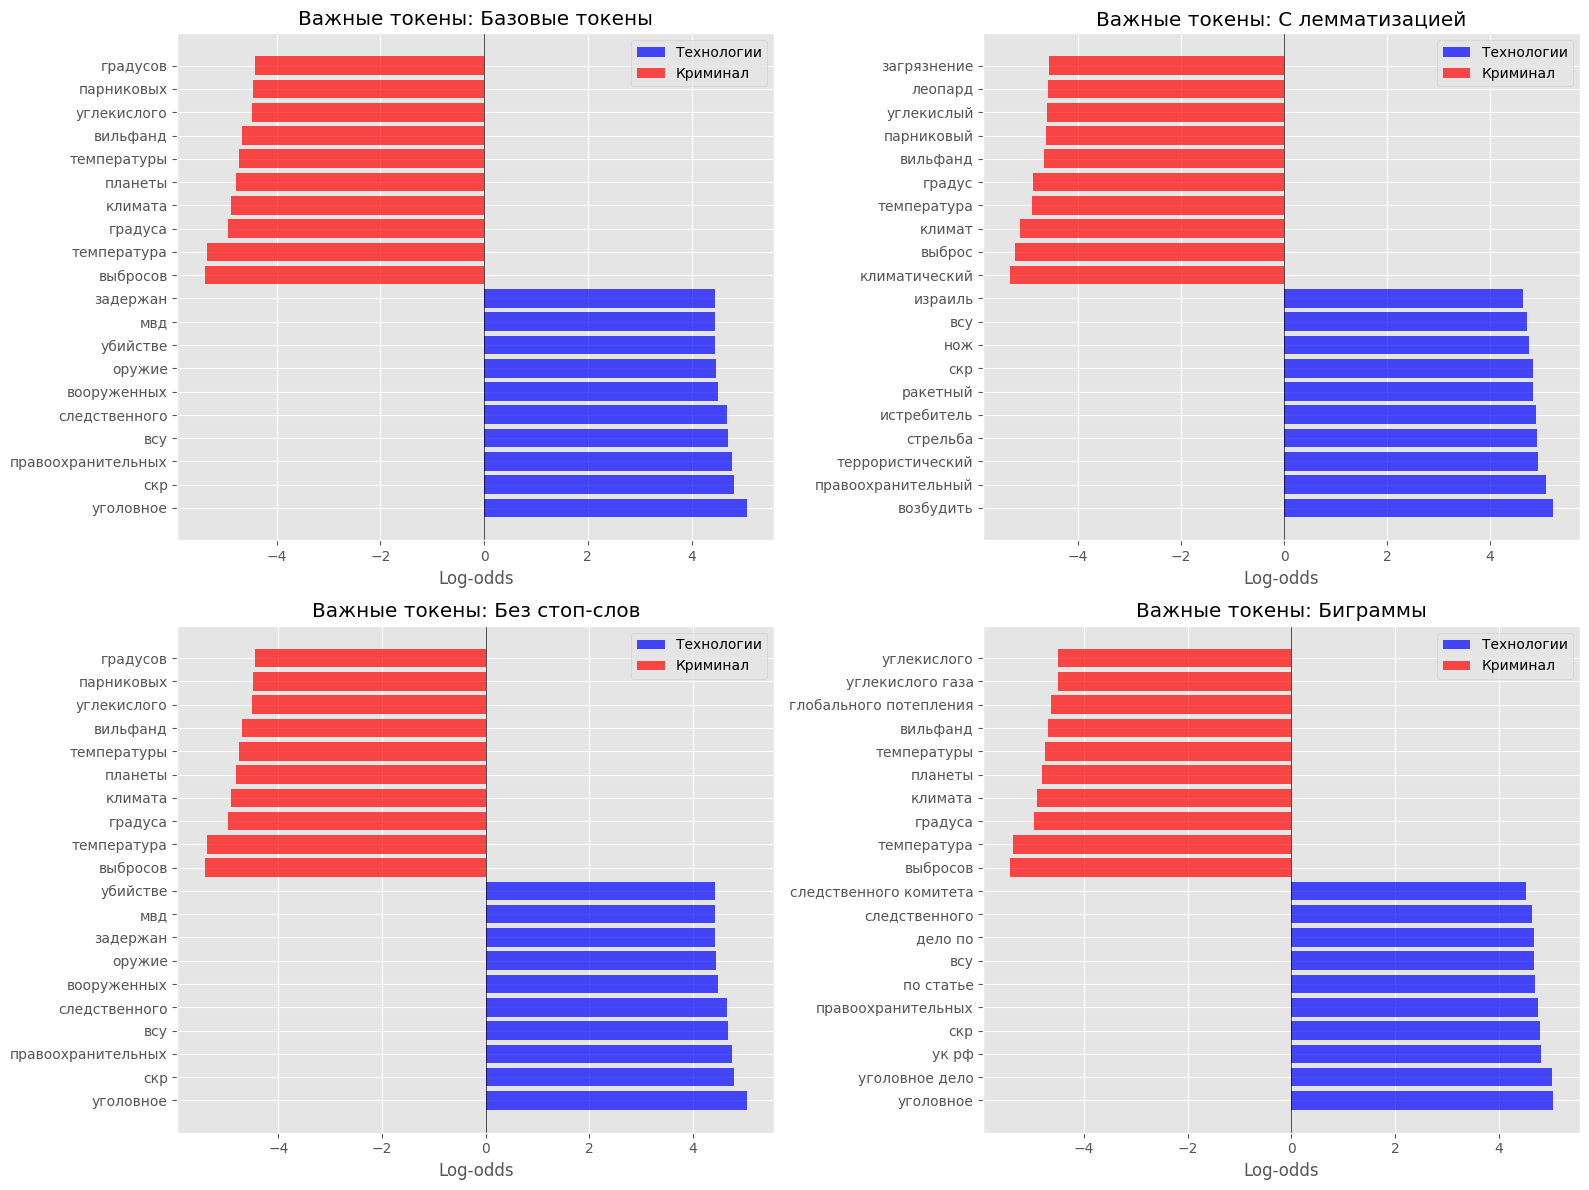

In [14]:
# @title A6. Визуализация сравнения важных токенов
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, (name, df_lo) in enumerate(results_log_odds.items()):
    row, col = idx//2, idx%2

    # Берем топ-10 с каждой стороны
    top_tech = df_lo.head(10)
    top_crime = df_lo.tail(10).sort_values('log_odds')

    axes[row, col].barh(range(10), top_tech['log_odds'].values, color='blue', alpha=0.7, label='Технологии')
    axes[row, col].barh(range(10, 20), top_crime['log_odds'].values, color='red', alpha=0.7, label='Криминал')
    axes[row, col].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

    # Объединяем названия
    all_tokens = list(top_tech['token']) + list(top_crime['token'])
    axes[row, col].set_yticks(range(20))
    axes[row, col].set_yticklabels(all_tokens)
    axes[row, col].set_title(f'Важные токены: {name}')
    axes[row, col].set_xlabel('Log-odds')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

In [15]:
# @title B1. Загрузка текстов двух авторов
from google.colab import files

print("Загрузите тексты двух разных авторов в формате .txt")
print("(например, Толстой и Достоевский, или Чехов и Бунин)")

print("\n--- АВТОР 1 ---")
uploaded1 = files.upload()
author1_name = list(uploaded1.keys())[0]
author1_text = uploaded1[author1_name].decode('utf-8')

print("\n--- АВТОР 2 ---")
uploaded2 = files.upload()
author2_name = list(uploaded2.keys())[0]
author2_text = uploaded2[author2_name].decode('utf-8')

print(f"\nАвтор 1 ({author1_name}): {len(author1_text)} символов")
print(f"Автор 2 ({author2_name}): {len(author2_text)} символов")

Загрузите тексты двух разных авторов в формате .txt
(например, Толстой и Достоевский, или Чехов и Бунин)

--- АВТОР 1 ---


Saving Герой нашего времени.txt to Герой нашего времени.txt

--- АВТОР 2 ---


Saving Отцы и дети.txt to Отцы и дети.txt

Автор 1 (Герой нашего времени.txt): 281815 символов
Автор 2 (Отцы и дети.txt): 370304 символов


In [16]:
# @title B2. Нарезка текстов на чанки
def create_chunks(text, chunk_size=150, overlap=30):
    """Разбивает текст на перекрывающиеся чанки указанного размера (в словах)"""
    words = re.findall(r'[а-яА-ЯёЁ]+', text)
    chunks = []
    step = chunk_size - overlap

    for i in range(0, len(words) - chunk_size + 1, step):
        chunk = ' '.join(words[i:i+chunk_size])
        chunks.append(chunk)

    return chunks

# Создаем чанки
chunk_size = 150
chunks_a1 = create_chunks(author1_text, chunk_size)
chunks_a2 = create_chunks(author2_text, chunk_size)

print(f"Автор 1: {len(chunks_a1)} чанков по ~{chunk_size} слов")
print(f"Автор 2: {len(chunks_a2)} чанков")

# Балансируем
min_chunks = min(len(chunks_a1), len(chunks_a2))
chunks_a1 = chunks_a1[:min_chunks]
chunks_a2 = chunks_a2[:min_chunks]

all_chunks = chunks_a1 + chunks_a2
labels = [0]*len(chunks_a1) + [1]*len(chunks_a2)

print(f"\nВсего чанков: {len(all_chunks)}, метки: {Counter(labels)}")

Автор 1: 348 чанков по ~150 слов
Автор 2: 469 чанков

Всего чанков: 696, метки: Counter({0: 348, 1: 348})


CLASSIFICATION REPORT:
                      precision    recall  f1-score   support

Герой нашего времени       1.00      0.99      1.00       105
     Отцы и дети.txt       0.99      1.00      1.00       104

            accuracy                           1.00       209
           macro avg       1.00      1.00      1.00       209
        weighted avg       1.00      1.00      1.00       209



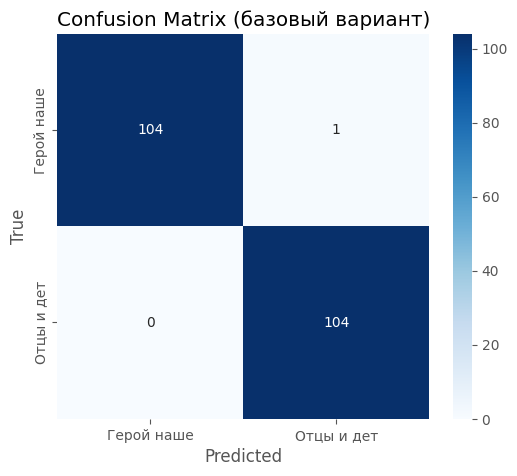

In [17]:
# @title B3. Обучение Naive Bayes (базовый вариант)
# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    all_chunks, labels, test_size=0.3, random_state=42, stratify=labels
)

# Векторизация
vectorizer = CountVectorizer(max_features=2000, preprocessor=lambda x: preprocess_text(x, lemmatize=False))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Обучение
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

# Предсказания
y_pred = nb.predict(X_test_vec)

# Оценка
print("CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=[author1_name[:20], author2_name[:20]]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[author1_name[:10], author2_name[:10]],
            yticklabels=[author1_name[:10], author2_name[:10]])
plt.title('Confusion Matrix (базовый вариант)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

ТОП-20 ДЛЯ Герой нашего времени:
 1. не                   (log-prob: -3.4773)
 2. что                  (log-prob: -3.6242)
 3. на                   (log-prob: -3.6617)
 4. он                   (log-prob: -4.0023)
 5. она                  (log-prob: -4.3758)
 6. как                  (log-prob: -4.4157)
 7. мне                  (log-prob: -4.4397)
 8. меня                 (log-prob: -4.5005)
 9. его                  (log-prob: -4.5154)
10. ее                   (log-prob: -4.6473)
11. то                   (log-prob: -4.7000)
12. за                   (log-prob: -4.7699)
13. все                  (log-prob: -4.8769)
14. но                   (log-prob: -4.8769)
15. это                  (log-prob: -4.8823)
16. по                   (log-prob: -4.9042)
17. вы                   (log-prob: -4.9494)
18. мы                   (log-prob: -4.9787)
19. сказал               (log-prob: -4.9907)
20. из                   (log-prob: -5.0722)

ТОП-20 ДЛЯ Отцы и дети.txt:
 1. не                   (log-prob: -3

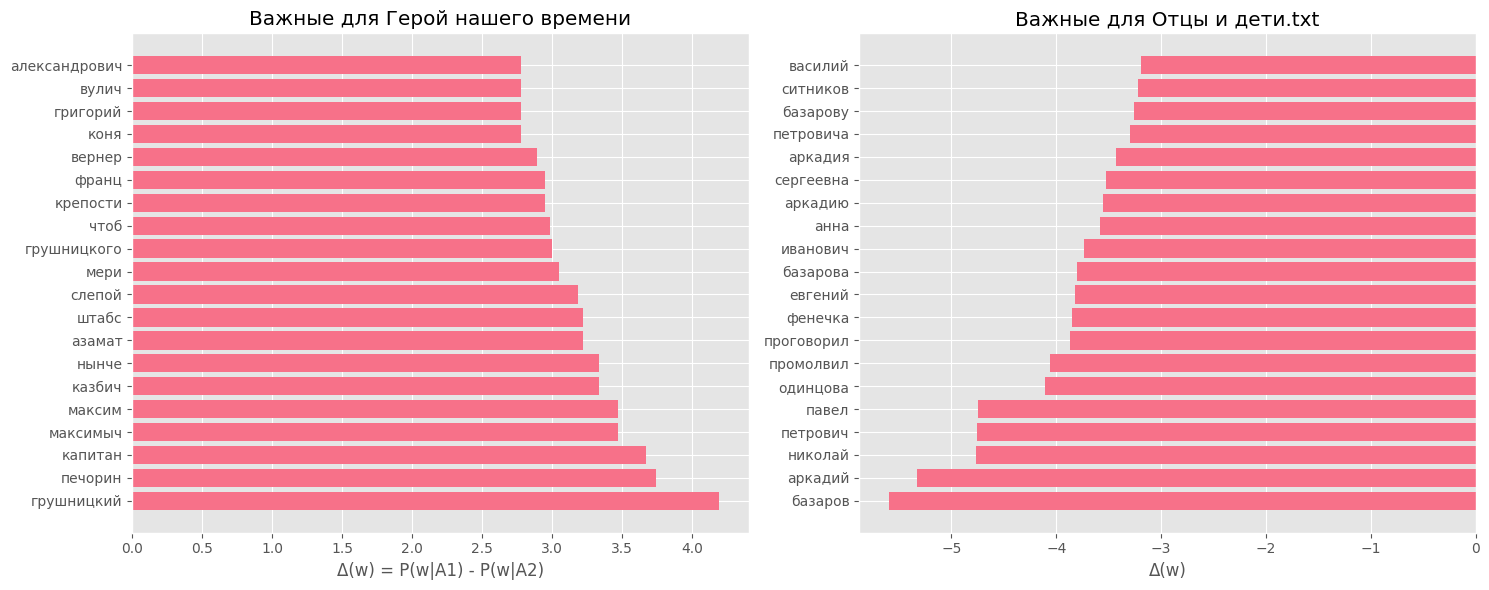

In [18]:
# @title B4. Важнейшие токены на основе Δ(w)
def get_important_features(nb_model, vectorizer, top_n=20):
    """Извлекает топ-N признаков для каждого класса"""
    feature_names = vectorizer.get_feature_names_out()
    log_probs = nb_model.feature_log_prob_

    # Для класса 0
    top_class0 = np.argsort(log_probs[0])[-top_n:][::-1]
    top_class1 = np.argsort(log_probs[1])[-top_n:][::-1]

    print(f"ТОП-{top_n} ДЛЯ {author1_name[:20]}:")
    for i, idx in enumerate(top_class0, 1):
        print(f"{i:2d}. {feature_names[idx]:20s} (log-prob: {log_probs[0][idx]:.4f})")

    print(f"\nТОП-{top_n} ДЛЯ {author2_name[:20]}:")
    for i, idx in enumerate(top_class1, 1):
        print(f"{i:2d}. {feature_names[idx]:20s} (log-prob: {log_probs[1][idx]:.4f})")

    return top_class0, top_class1

top0, top1 = get_important_features(nb, vectorizer)

# Визуализация Δ(w) - разница вероятностей
feature_names = vectorizer.get_feature_names_out()
delta = nb.feature_log_prob_[0] - nb.feature_log_prob_[1]

# Топ для автора 1 (положительная дельта)
top_delta_idx = np.argsort(delta)[-20:][::-1]
# Топ для автора 2 (отрицательная дельта)
bottom_delta_idx = np.argsort(delta)[:20]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Автор 1
axes[0].barh(range(20), delta[top_delta_idx])
axes[0].set_yticks(range(20))
axes[0].set_yticklabels([feature_names[i] for i in top_delta_idx])
axes[0].set_title(f'Важные для {author1_name[:20]}')
axes[0].set_xlabel('Δ(w) = P(w|A1) - P(w|A2)')

# Автор 2
axes[1].barh(range(20), delta[bottom_delta_idx])
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([feature_names[i] for i in bottom_delta_idx])
axes[1].set_title(f'Важные для {author2_name[:20]}')
axes[1].set_xlabel('Δ(w)')

plt.tight_layout()
plt.show()

In [19]:
# @title B5. Сравнение с лемматизацией, n-граммами, стоп-словами
variants_nb = [
    {'name': 'Базовый', 'lemmatize': False, 'remove_stops': False, 'ngram': (1,1)},
    {'name': 'С лемматизацией', 'lemmatize': True, 'remove_stops': False, 'ngram': (1,1)},
    {'name': 'Без стоп-слов', 'lemmatize': False, 'remove_stops': True, 'ngram': (1,1)},
    {'name': 'С биграммами', 'lemmatize': False, 'remove_stops': False, 'ngram': (1,2)},
]

results_nb = {}

for var in variants_nb:
    print(f"\n{'='*60}")
    print(f"ВАРИАНТ: {var['name']}")
    print('='*60)

    # Векторизация
    vectorizer = CountVectorizer(
        max_features=2000,
        ngram_range=var['ngram'],
        preprocessor=lambda x: preprocess_text(x, var['lemmatize'], var['remove_stops'])
    )
    X_vec = vectorizer.fit_transform(all_chunks)

    # Разделение
    X_train, X_test, y_train, y_test = train_test_split(
        X_vec, labels, test_size=0.3, random_state=42, stratify=labels
    )

    # Обучение
    nb = MultinomialNB()
    nb.fit(X_train, y_train)

    # Оценка
    y_pred = nb.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)

    results_nb[var['name']] = {
        'model': nb,
        'vectorizer': vectorizer,
        'accuracy': report['accuracy'],
        'f1_macro': report['macro avg']['f1-score'],
        'feature_names': vectorizer.get_feature_names_out()
    }

    print(f"Accuracy: {report['accuracy']:.4f}")
    print(f"F1-macro: {report['macro avg']['f1-score']:.4f}")

    # Важные токены
    log_probs = nb.feature_log_prob_
    feature_names = vectorizer.get_feature_names_out()

    print(f"\nТоп-10 для автора 1:")
    top_idx = np.argsort(log_probs[0])[-10:][::-1]
    for idx in top_idx:
        print(f"  {feature_names[idx]}")

    print(f"Топ-10 для автора 2:")
    top_idx = np.argsort(log_probs[1])[-10:][::-1]
    for idx in top_idx:
        print(f"  {feature_names[idx]}")


ВАРИАНТ: Базовый
Accuracy: 0.9904
F1-macro: 0.9904

Топ-10 для автора 1:
  не
  что
  на
  он
  она
  как
  мне
  меня
  его
  ее
Топ-10 для автора 2:
  не
  он
  на
  что
  его
  как
  она
  базаров
  вы
  но

ВАРИАНТ: С лемматизацией
Accuracy: 1.0000
F1-macro: 1.0000

Топ-10 для автора 1:
  не
  что
  на
  он
  быть
  она
  как
  мне
  меня
  это
Топ-10 для автора 2:
  не
  он
  что
  на
  она
  это
  как
  петрович
  вы
  базаров

ВАРИАНТ: Без стоп-слов
Accuracy: 0.9856
F1-macro: 0.9856

Топ-10 для автора 1:
  сказал
  ни
  отвечал
  грушницкий
  глаза
  раз
  два
  печорин
  руку
  доктор
Топ-10 для автора 2:
  базаров
  петрович
  аркадий
  николай
  павел
  ни
  одинцова
  промолвил
  заметил
  человек

ВАРИАНТ: С биграммами
Accuracy: 0.9952
F1-macro: 0.9952

Топ-10 для автора 1:
  не
  что
  на
  он
  она
  как
  мне
  меня
  его
  ее
Топ-10 для автора 2:
  не
  он
  на
  что
  его
  как
  она
  базаров
  вы
  но


ЗАГРУЗИТЕ ТЕКСТ ДРУГОГО ЖАНРА (например, стихи или пьесы)
для проверки domain shift


Saving Евгений Онегин.txt to Евгений Онегин.txt
Создано 209 чанков из Евгений Онегин.txt

РЕЗУЛЬТАТЫ DOMAIN SHIFT:
Предсказания для 209 чанков:
  Класс 0 (Герой нашего времени.txt): 161 чанков (77.0%)
  Класс 1 (Отцы и дети.txt): 48 чанков (23.0%)
Средняя уверенность предсказаний: 0.922


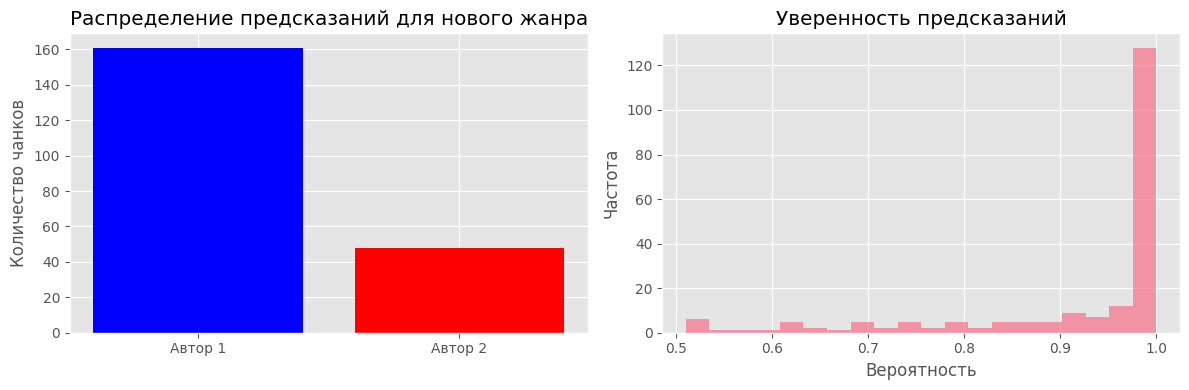

In [20]:
# @title B7. Domain Shift: проза → стихи (или другой жанр)
print("ЗАГРУЗИТЕ ТЕКСТ ДРУГОГО ЖАНРА (например, стихи или пьесы)")
print("для проверки domain shift")

from google.colab import files
uploaded_shift = files.upload()
shift_file = list(uploaded_shift.keys())[0]
shift_text = uploaded_shift[shift_file].decode('utf-8')

# Создаем чанки из нового жанра
shift_chunks = create_chunks(shift_text, chunk_size=150)
print(f"Создано {len(shift_chunks)} чанков из {shift_file}")

# Используем лучшую модель из предыдущего шага (например, с лемматизацией)
best_var = 'С лемматизацией'  # выберите лучший вариант
best_model = results_nb[best_var]['model']
best_vectorizer = results_nb[best_var]['vectorizer']

# Преобразуем новые чанки
X_shift = best_vectorizer.transform(shift_chunks)

# Предсказываем "автора" для нового жанра
shift_pred = best_model.predict(X_shift)
pred_dist = Counter(shift_pred)

print(f"\nРЕЗУЛЬТАТЫ DOMAIN SHIFT:")
print(f"Предсказания для {len(shift_chunks)} чанков:")
print(f"  Класс 0 ({author1_name[:30]}): {pred_dist[0]} чанков ({pred_dist[0]/len(shift_chunks):.1%})")
print(f"  Класс 1 ({author2_name[:30]}): {pred_dist[1]} чанков ({pred_dist[1]/len(shift_chunks):.1%})")

# Уверенность предсказаний
probs = best_model.predict_proba(X_shift)
avg_confidence = np.mean(np.max(probs, axis=1))
print(f"Средняя уверенность предсказаний: {avg_confidence:.3f}")

# Визуализация распределения предсказаний
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Автор 1', 'Автор 2'], [pred_dist[0], pred_dist[1]], color=['blue', 'red'])
axes[0].set_title('Распределение предсказаний для нового жанра')
axes[0].set_ylabel('Количество чанков')

axes[1].hist(np.max(probs, axis=1), bins=20, alpha=0.7)
axes[1].set_title('Уверенность предсказаний')
axes[1].set_xlabel('Вероятность')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()